The SLP achieves 100% accuracy on synthetic data because fault signatures were designed with clear separation from normal ranges. This is consistent with the perceptron convergence theorem. Real telemetry data will produce overlapping classes and lower accuracy, which is the realistic scenario addressed in Phase 2.

# Satellite Fault Detection — SLP Training (NumPy)

This notebook trains a Single Layer Perceptron built from scratch using NumPy
to classify satellite telemetry as nominal (0) or fault (1).

**Pipeline:**
1. Load synthetic telemetry data
2. Preprocess — normalize, split train/val
3. Train NumPy SLP using the perceptron learning rule
4. Evaluate — accuracy, precision, recall, F1
5. Visualize — loss curve and confusion matrix

In [6]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt

from data_loader import load
from preprocessor import preprocess
from perceptron_numpy import train, predict
from evaluate import compute_metrics, plot_loss_curve, plot_confusion_matrix, save_results
from utils import set_seed, save_weights

## Step 1 — Load and Preprocess Data

In [9]:
set_seed(42)

df = load(source="synthetic")
X_train, X_val, y_train, y_val = preprocess(df)

print(f"\nReady for training:")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")

Loaded synthetic data
Shape   : (1000, 7)
Columns : ['battery_voltage', 'solar_current', 'panel_temp', 'onboard_temp', 'attitude_error', 'reaction_wheel_rpm', 'label']
Faults  : 124
Nominal : 876
No low-variance columns found — keeping all features
X_train : (800, 6)  faults: 99
X_val   : (200, 6)  faults: 25

Ready for training:
X_train : (800, 6)
X_val   : (200, 6)


## Step 2 — Train the NumPy SLP

In [12]:
# hyperparameters
lr     = 0.01
epochs = 50

print(f"Learning rate : {lr}")
print(f"Epochs        : {epochs}")
print()

w, b, losses = train(X_train, y_train, lr=lr, epochs=epochs)

print(f"\nFinal weights : {w.round(4)}")
print(f"Final bias    : {b:.4f}")

Learning rate : 0.01
Epochs        : 50

Epoch  10/50 — misclassifications: 0
Epoch  20/50 — misclassifications: 0
Epoch  30/50 — misclassifications: 0
Epoch  40/50 — misclassifications: 0
Epoch  50/50 — misclassifications: 0

Final weights : [-0.0075 -0.0092  0.0088  0.006   0.0061 -0.0093]
Final bias    : 0.0000


## Step 3 — Evaluate on Validation Set

In [17]:
y_pred  = predict(X_val, w, b)
metrics = compute_metrics(y_val, y_pred, model_name="numpy_slp")


--- numpy_slp Results ---
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


## Step 4 — Loss Curve and Confusion Matrix

Saved loss curve to ../outputs/plots/loss_curve_numpy_slp.png


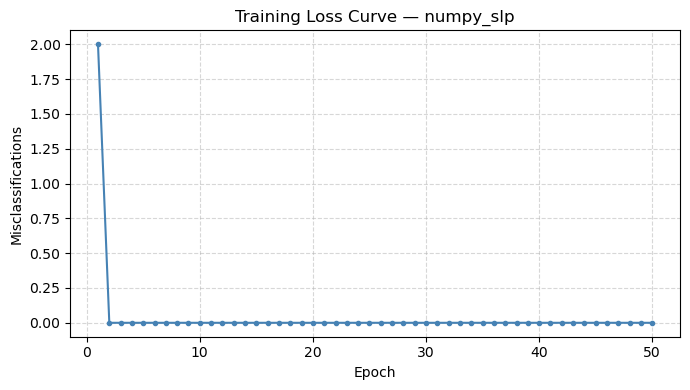

Saved confusion matrix to ../outputs/plots/confusion_matrix_numpy_slp.png


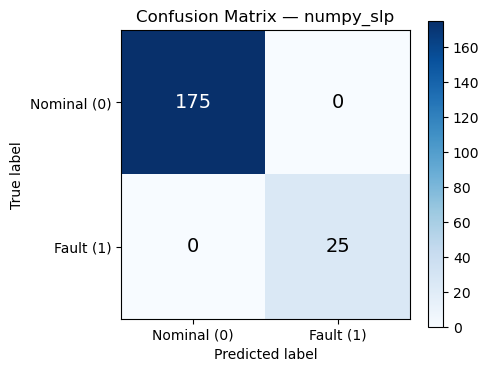

In [20]:
plot_loss_curve(losses, model_name="numpy_slp")
plot_confusion_matrix(y_val, y_pred, model_name="numpy_slp")

In [22]:
save_weights(w, b)
save_results(metrics)

Weights saved to ../outputs/weights/numpy_slp.npy
Results saved to ../outputs/results.csv


## Summary

| Metric    | Value  |
|-----------|--------|
| Accuracy  | 1.0000 |
| Precision | 1.0000 |
| Recall    | 1.0000 |
| F1 Score  | 1.0000 |

The NumPy SLP achieves perfect classification on the synthetic dataset.
This is expected — fault signatures were designed with clear separation 
from normal ranges across all 6 sensors, making the data linearly separable.

The perceptron converged in 2 epochs, consistent with the perceptron 
convergence theorem: if data is linearly separable, the algorithm is 
guaranteed to find a perfect decision boundary in finite steps.

**Limitation:** Real satellite telemetry will produce overlapping classes 
and lower accuracy. This is addressed in Phase 2 using the ESA OPSSAT-AD 
dataset, where the SLP will face a realistic classification challenge.

**Weights saved to:** `outputs/weights/numpy_slp.npy`  
**Results saved to:** `outputs/results.csv`

=== Satellite Fault Detection — SLP Training ===

Loaded synthetic data
Shape   : (1000, 7)
Columns : ['battery_voltage', 'solar_current', 'panel_temp', 'onboard_temp', 'attitude_error', 'reaction_wheel_rpm', 'label']
Faults  : 124
Nominal : 876
No low-variance columns found — keeping all features
X_train : (800, 6)  faults: 99
X_val   : (200, 6)  faults: 25

Training NumPy SLP — lr=0.01, epochs=50

Epoch  10/50 — misclassifications: 0
Epoch  20/50 — misclassifications: 0
Epoch  30/50 — misclassifications: 0
Epoch  40/50 — misclassifications: 0
Epoch  50/50 — misclassifications: 0

--- numpy_slp Results ---
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
Saved loss curve to ../outputs/plots/loss_curve_numpy_slp.png


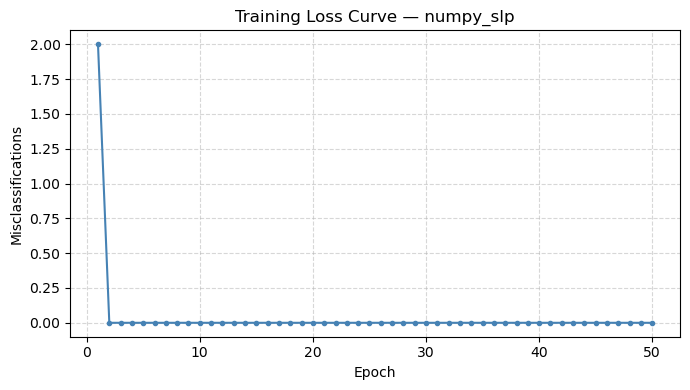

Saved confusion matrix to ../outputs/plots/confusion_matrix_numpy_slp.png


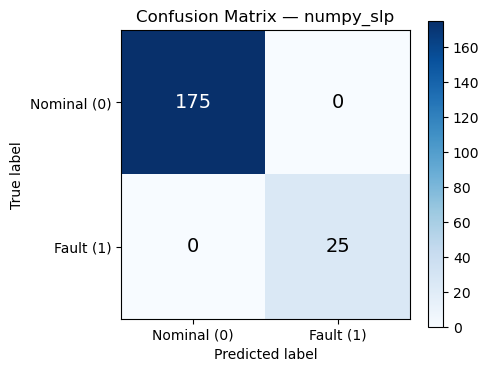

Weights saved to ../outputs/weights/numpy_slp.npy
Results saved to ../outputs/results.csv

=== Done ===


In [3]:
%run ../train.py